In [ ]:
import numpy as np
import pandas as pd

## Data Pre-Processing

In [ ]:
data = pd.read_csv('DATA_SAHAM_22-24.csv', sep=',')
data.head()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,30/12/2024,"7.079,90","7.026,78","7.079,90","6.993,07","15,97B","0,62%"
1,27/12/2024,"7.036,57","7.073,38","7.100,27","7.024,71","14,43B","-0,41%"
2,24/12/2024,"7.065,75","7.115,64","7.120,58","7.063,75","11,06B","-0,43%"
3,23/12/2024,"7.096,44","7.037,53","7.096,44","7.035,73","13,87B","1,61%"
4,20/12/2024,"6.983,87","6.980,17","7.032,40","6.931,58","14,57B","0,09%"


In [ ]:
data['Tanggal'] = pd.to_datetime(data['Tanggal'])

/tmp/ipython-input-3761121070.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Tanggal'] = pd.to_datetime(data['Tanggal'])


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Tanggal     724 non-null    datetime64[ns]
 1   Terakhir    724 non-null    object        
 2   Pembukaan   724 non-null    object        
 3   Tertinggi   724 non-null    object        
 4   Terendah    724 non-null    object        
 5   Vol.        722 non-null    object        
 6   Perubahan%  724 non-null    object        
dtypes: datetime64[ns](1), object(6)
memory usage: 39.7+ KB


In [ ]:
data['Tanggal'] = pd.to_datetime(data['Tanggal'])

In [ ]:
for col in ['Terakhir', 'Pembukaan', 'Tertinggi', 'Terendah']:
    data[col] = data[col].str.replace('.', '', regex=False)  # menghilangkan titik pada ribuan
    data[col] = data[col].str.replace(',', '.', regex=False) # mengganti koma pada akhir menjadi titik
    data[col] = data[col].astype(float)

In [ ]:
data.head()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,2024-12-30,7079.90,7026.78,7079.90,6993.07,"15,97B","0,62%"
1,2024-12-27,7036.57,7073.38,7100.27,7024.71,"14,43B","-0,41%"
2,2024-12-24,7065.75,7115.64,7120.58,7063.75,"11,06B","-0,43%"
3,2024-12-23,7096.44,7037.53,7096.44,7035.73,"13,87B","1,61%"
4,2024-12-20,6983.87,6980.17,7032.40,6931.58,"14,57B","0,09%"


In [ ]:
data['Vol.'] = data['Vol.'].str.replace('B', '', regex=False)  # menghapus huruf B
data['Vol.'] = data['Vol.'].str.replace('.', '', regex=False)  # menghilangkan titik pada ribuan
data['Vol.'] = data['Vol.'].str.replace(',', '.', regex=False) # mengganti koma pada akhir menjadi titik
data['Vol.'] = data['Vol.'].astype(float) * 1_000_000_000      # mengganti B menjadi anggka miliar

In [ ]:
data['Perubahan%'] = data['Perubahan%'].str.replace('%', '', regex=False) # menghapus simbol %
data['Perubahan%'] = data['Perubahan%'].str.replace(',', '.', regex=False)
data['Perubahan%'] = data['Perubahan%'].astype(float)

In [ ]:
data.describe()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
count,724,724.000000,724.000000,724.000000,724.000000,7.220000e+02,724.000000
mean,2023-07-01 06:21:52.707182336,7041.627583,7043.028826,7079.471215,7003.692113,1.812870e+10,0.013066
min,2022-01-03 00:00:00,6565.730000,6565.730000,6601.340000,6509.880000,8.520000e+09,-4.420000
25%,2022-10-02 06:00:00,6840.440000,6839.335000,6879.395000,6808.695000,1.446500e+10,-0.440000
50%,2023-07-04 12:00:00,7009.675000,7011.260000,7048.005000,6970.020000,1.705500e+10,0.040000
75%,2024-03-27 06:00:00,7219.100000,7220.447500,7258.400000,7180.210000,2.059000e+10,0.500000
max,2024-12-30 00:00:00,7905.390000,7904.400000,7910.560000,7853.350000,6.151000e+10,2.240000
std,NaN,270.106502,271.231602,270.863802,270.653283,5.257729e+09,0.756716


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Tanggal     724 non-null    datetime64[ns]
 1   Terakhir    724 non-null    float64       
 2   Pembukaan   724 non-null    float64       
 3   Tertinggi   724 non-null    float64       
 4   Terendah    724 non-null    float64       
 5   Vol.        722 non-null    float64       
 6   Perubahan%  724 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 39.7 KB


In [ ]:
data = data.sort_values('Tanggal')

In [ ]:
data.tail()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
4,2024-12-20,6983.87,6980.17,7032.40,6931.58,1.457000e+10,0.09
3,2024-12-23,7096.44,7037.53,7096.44,7035.73,1.387000e+10,1.61
2,2024-12-24,7065.75,7115.64,7120.58,7063.75,1.106000e+10,-0.43
1,2024-12-27,7036.57,7073.38,7100.27,7024.71,1.443000e+10,-0.41
0,2024-12-30,7079.90,7026.78,7079.90,6993.07,1.597000e+10,0.62


In [ ]:
data.head()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
723,2022-01-03,6665.31,6586.26,6677.20,6586.13,1.826000e+10,1.27
722,2022-01-04,6695.37,6675.13,6720.66,6675.13,1.859000e+10,0.45
721,2022-01-05,6662.30,6703.17,6738.11,6634.84,1.791000e+10,-0.49
720,2022-01-06,6653.35,6674.85,6679.85,6593.23,1.800000e+10,-0.13
719,2022-01-07,6701.32,6669.51,6712.15,6647.71,1.571000e+10,0.72


In [ ]:
print(data.isnull().sum())

Tanggal       0
Terakhir      0
Pembukaan     0
Tertinggi     0
Terendah      0
Vol.          2
Perubahan%    0
dtype: int64


In [ ]:
# menghapus missing value
data = data.dropna(subset=['Vol.'])

In [ ]:
print(data.isnull().sum())

Tanggal       0
Terakhir      0
Pembukaan     0
Tertinggi     0
Terendah      0
Vol.          0
Perubahan%    0
dtype: int64


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 722 entries, 723 to 0
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Tanggal     722 non-null    datetime64[ns]
 1   Terakhir    722 non-null    float64       
 2   Pembukaan   722 non-null    float64       
 3   Tertinggi   722 non-null    float64       
 4   Terendah    722 non-null    float64       
 5   Vol.        722 non-null    float64       
 6   Perubahan%  722 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 45.1 KB


In [ ]:
data.to_csv('SAHAM_CLEAN_22-24.csv', index=False)

## Exploratory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


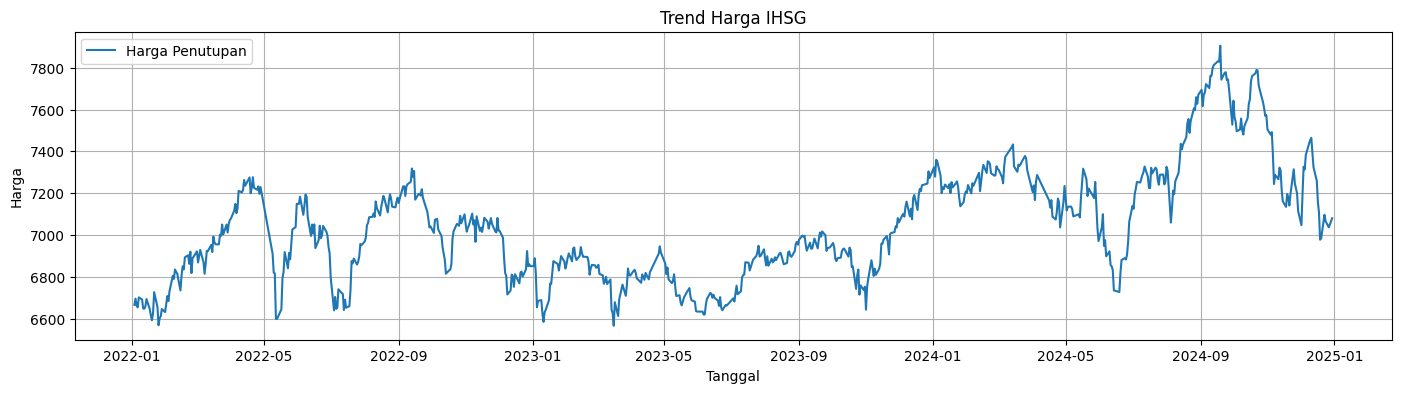

In [ ]:
plt.figure(figsize=(17,4))
plt.plot(data['Tanggal'], data['Terakhir'], label='Harga Penutupan')
plt.title('Trend Harga IHSG')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid()
plt.show()

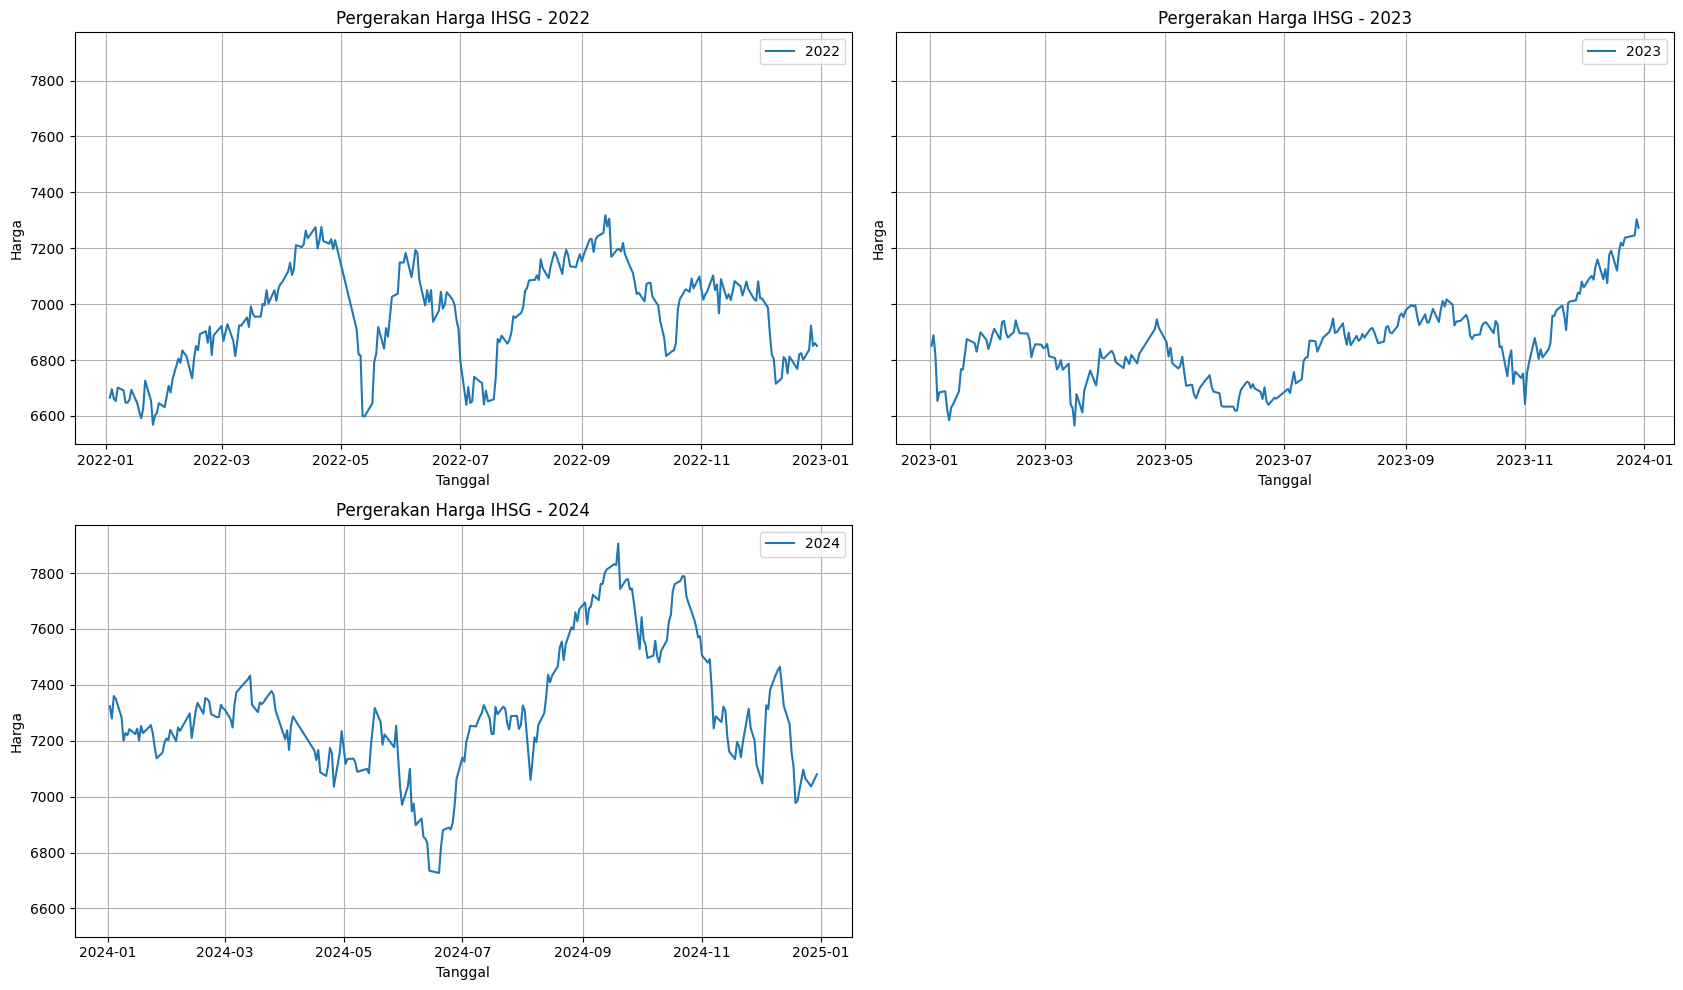

In [ ]:

data['Tahun'] = data['Tanggal'].dt.year
tahun_unik = sorted(data['Tahun'].unique())
n = len(tahun_unik)
ncols = 2
nrows = (n + 1) // ncols
fig, axs = plt.subplots(nrows, ncols, figsize=(17, 10), sharey=True)
axs = axs.flatten()

for i, tahun in enumerate(tahun_unik):
    data_tahun = data[data['Tahun'] == tahun]
    axs[i].plot(data_tahun['Tanggal'], data_tahun['Terakhir'], label=f'{tahun}', color='tab:blue')
    axs[i].set_title(f'Pergerakan Harga IHSG - {tahun}')
    axs[i].set_xlabel('Tanggal')
    axs[i].set_ylabel('Harga')
    axs[i].grid(True)
    axs[i].legend()

# Sembunyikan subplot kosong jika ada
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.tight_layout()
plt.show()

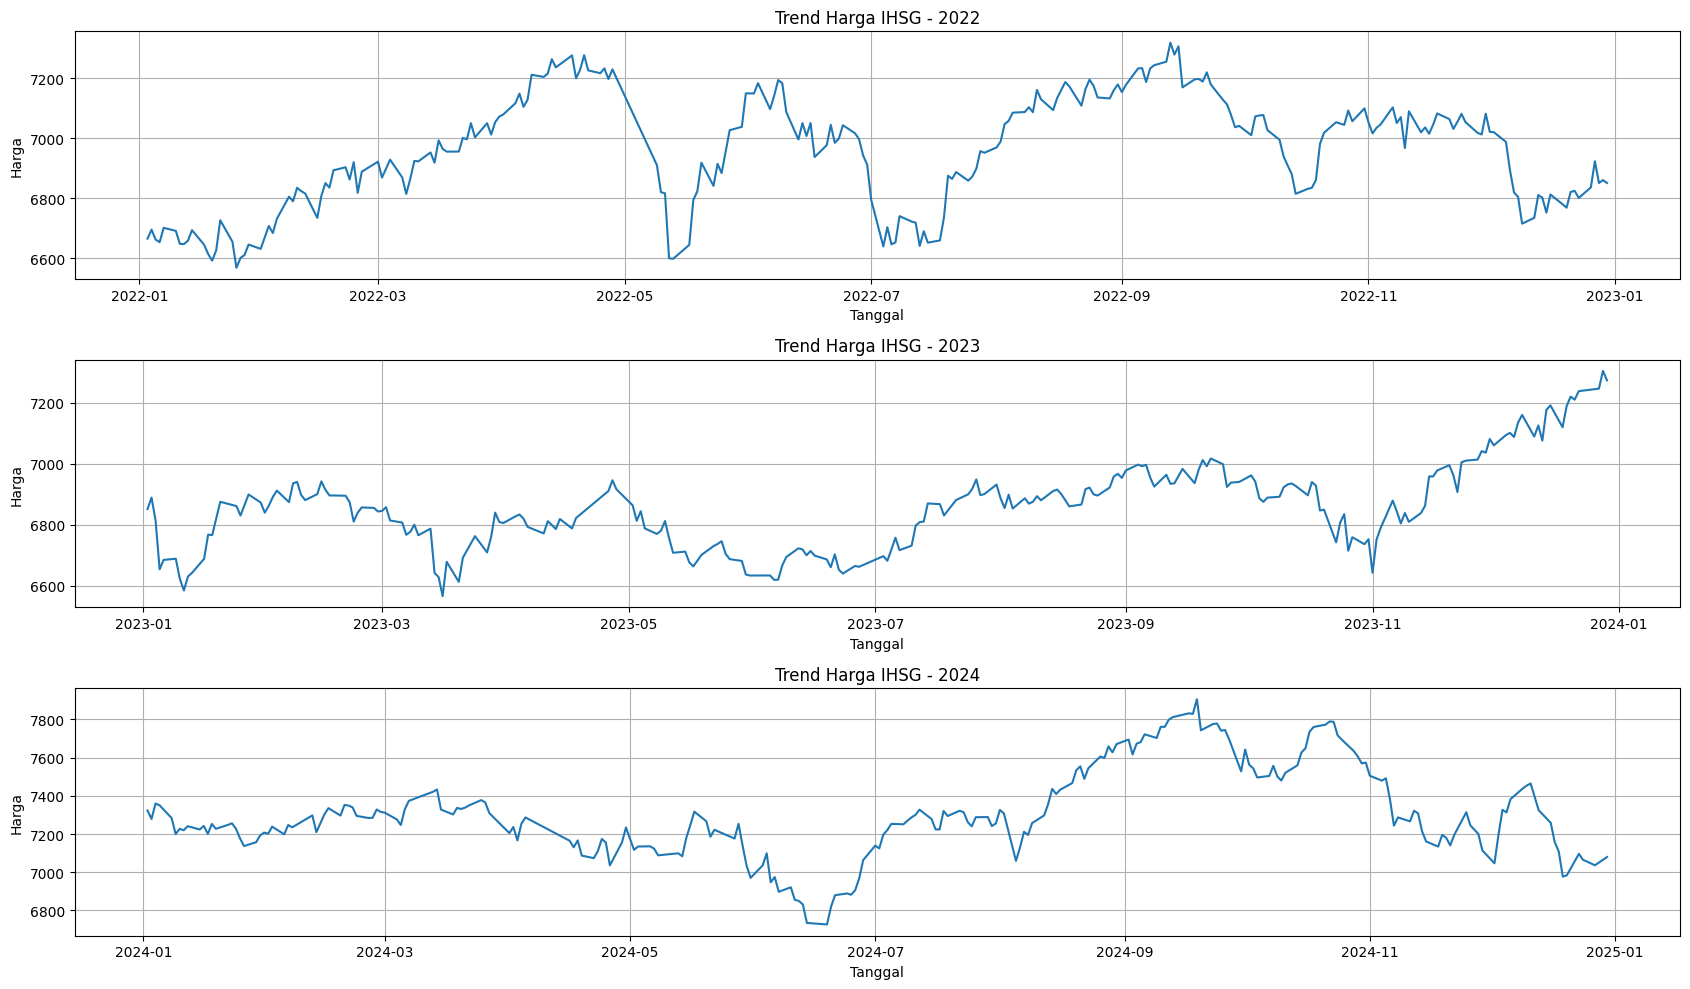

In [ ]:
# pergerakan harga per-tahun

data['Tahun'] = data['Tanggal'].dt.year
tahun_unik = sorted(data['Tahun'].unique())
plt.figure(figsize=(17, 10))

for i, tahun in enumerate(tahun_unik, 1):
    plt.subplot(len(tahun_unik), 1, i)
    subset = data[data['Tahun'] == tahun]
    plt.plot(subset['Tanggal'], subset['Terakhir'], label=f'{tahun}')
    plt.title(f'Trend Harga IHSG - {tahun}')
    plt.xlabel('Tanggal')
    plt.ylabel('Harga')
    plt.grid(True)
    plt.tight_layout()

plt.show()

In [ ]:
# Calculate yearly averages to assess temperature rise
results_df = pd.DataFrame({
    'Date': data['Tanggal'],
    'Actual': data['Perubahan%'].values.flatten(),  # Access 'Temperature' column and then flatten
})
results_df['Year'] = results_df['Date'].dt.year

yearly_avg = results_df.groupby('Year')[['Actual']].mean()
print("Yearly Average IHSG Price:\n",yearly_avg)

Yearly Average IHSG Price:
         Actual
Year          
2022  0.019715
2023  0.026904
2024 -0.007679


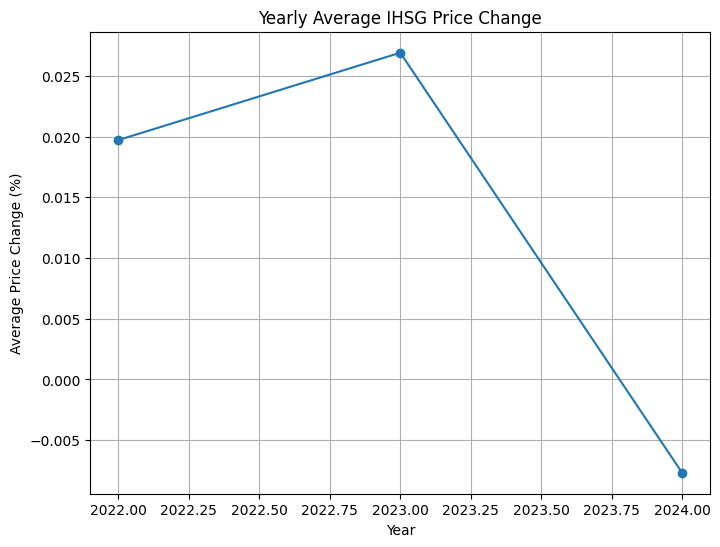

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(yearly_avg.index, yearly_avg['Actual'], marker='o')
plt.title('Yearly Average IHSG Price Change')
plt.xlabel('Year')
plt.ylabel('Average Price Change (%)')
plt.grid(True)
plt.show()

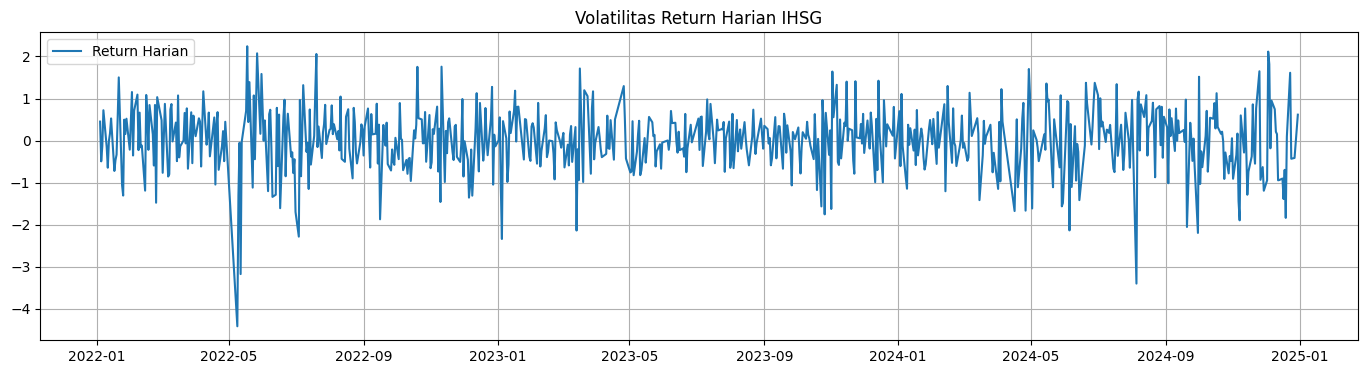

In [ ]:
data['Return'] = data['Terakhir'].pct_change() * 100
plt.figure(figsize=(17,4))
plt.plot(data['Tanggal'], data['Return'], label='Return Harian')
plt.title('Volatilitas Return Harian IHSG')
plt.grid()
plt.legend()
plt.show()

# Menghitung return harian (persentase perubahan harga dari hari ke hari).
# Return harian mencerminkan volatilitas pasar dalam jangka pendek.
# Fitur ini umum digunakan sebagai input atau target dalam model prediksi harga saham.

# Cocok digunakan sebagai:
# Fitur prediktor (X) jika kamu ingin memprediksi harga atau return di masa depan.
# Target (y) jika model memprediksi arah atau besarnya return.

In [ ]:
import pandas as pd
data = pd.read_csv('DATA_SAHAM_22-24_CLEAN.csv', sep=',')
data

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,2022-01-03,6665.31,6586.26,6677.20,6586.13,1.826000e+10,1.27
1,2022-01-04,6695.37,6675.13,6720.66,6675.13,1.859000e+10,0.45
2,2022-01-05,6662.30,6703.17,6738.11,6634.84,1.791000e+10,-0.49
3,2022-01-06,6653.35,6674.85,6679.85,6593.23,1.800000e+10,-0.13
4,2022-01-07,6701.32,6669.51,6712.15,6647.71,1.571000e+10,0.72
...,...,...,...,...,...,...,...
717,2024-12-20,6983.87,6980.17,7032.40,6931.58,1.457000e+10,0.09
718,2024-12-23,7096.44,7037.53,7096.44,7035.73,1.387000e+10,1.61
719,2024-12-24,7065.75,7115.64,7120.58,7063.75,1.106000e+10,-0.43
720,2024-12-27,7036.57,7073.38,7100.27,7024.71,1.443000e+10,-0.41


In [ ]:
data = pd.read_csv("DATA_SAHAM_22-24_CLEAN.csv")
data

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,2022-01-03,6665.31,6586.26,6677.20,6586.13,1.826000e+10,1.27
1,2022-01-04,6695.37,6675.13,6720.66,6675.13,1.859000e+10,0.45
2,2022-01-05,6662.30,6703.17,6738.11,6634.84,1.791000e+10,-0.49
3,2022-01-06,6653.35,6674.85,6679.85,6593.23,1.800000e+10,-0.13
4,2022-01-07,6701.32,6669.51,6712.15,6647.71,1.571000e+10,0.72
...,...,...,...,...,...,...,...
717,2024-12-20,6983.87,6980.17,7032.40,6931.58,1.457000e+10,0.09
718,2024-12-23,7096.44,7037.53,7096.44,7035.73,1.387000e+10,1.61
719,2024-12-24,7065.75,7115.64,7120.58,7063.75,1.106000e+10,-0.43
720,2024-12-27,7036.57,7073.38,7100.27,7024.71,1.443000e+10,-0.41


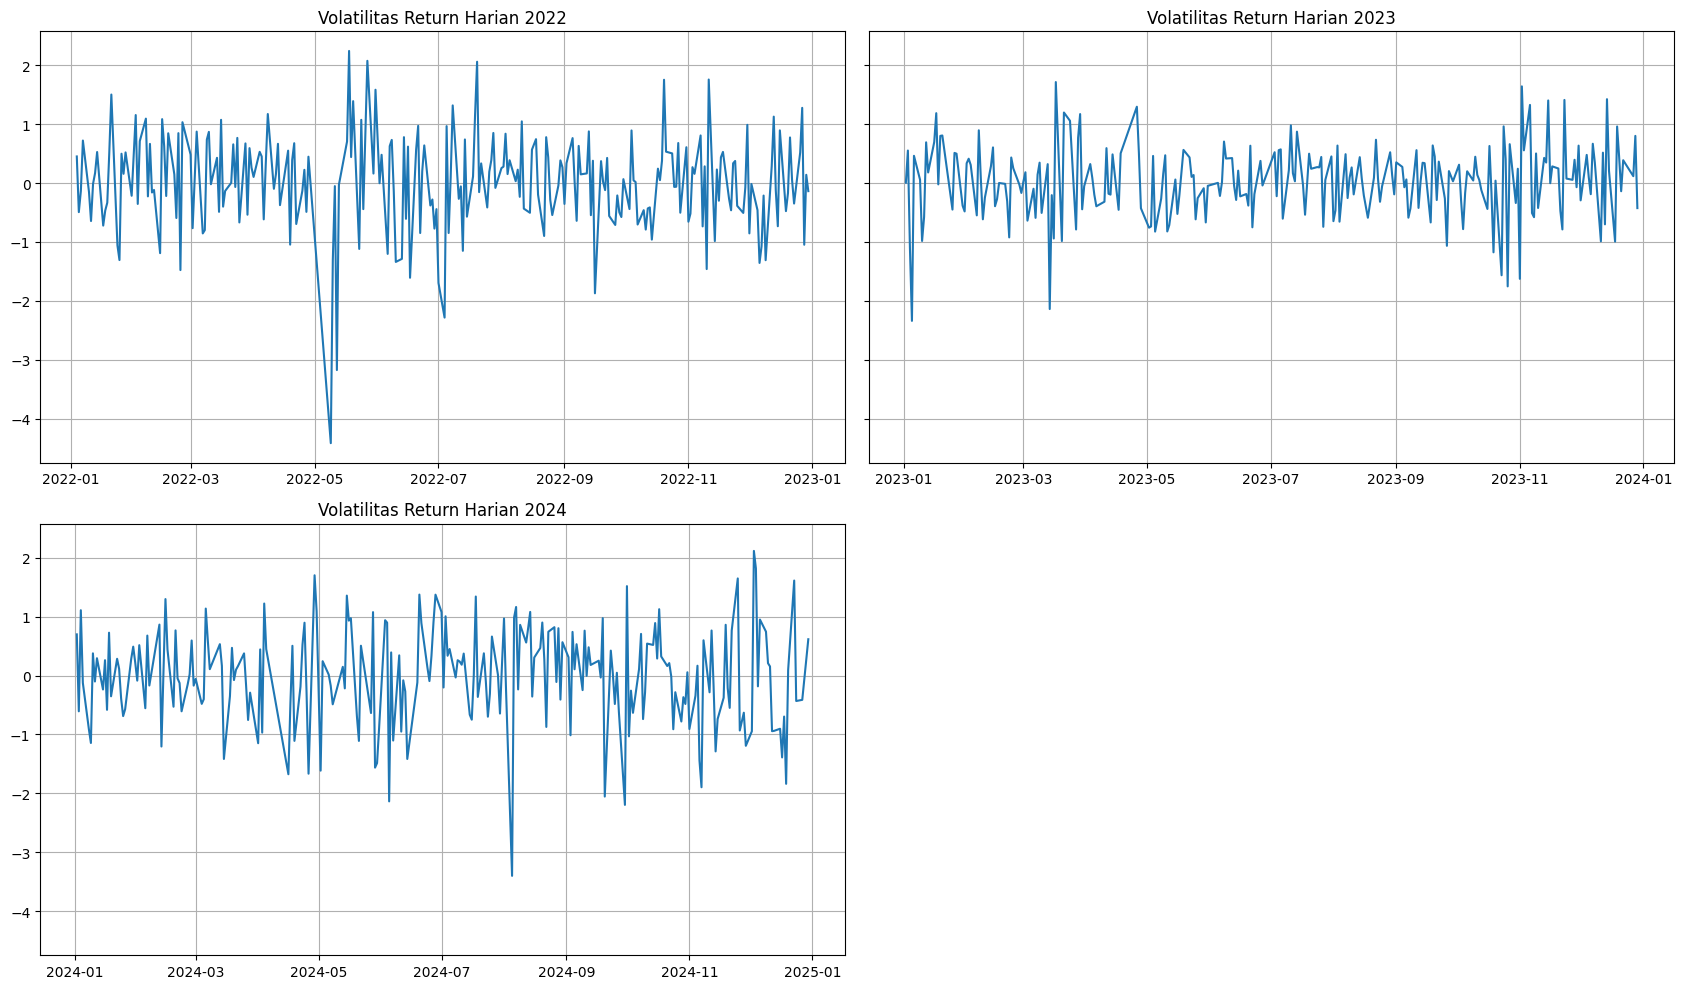

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Pastikan datetime
data['Tanggal'] = pd.to_datetime(data['Tanggal'], errors='coerce')
data['Tahun'] = data['Tanggal'].dt.year

# Hitung return
data['Return'] = data['Terakhir'].pct_change() * 100

# 🔥 FILTER TAHUN SAJA (NO NAN)
tahun_unik = [2022, 2023, 2024]

fig, axs = plt.subplots(2, 2, figsize=(17, 10), sharey=True)
axs = axs.flatten()

for i, tahun in enumerate(tahun_unik):
    d = data[data['Tahun'] == tahun]
    axs[i].plot(d['Tanggal'], d['Return'])
    axs[i].set_title(f'Volatilitas Return Harian {tahun}')
    axs[i].grid()

# Sembunyikan 1 subplot sisa
axs[3].set_visible(False)

plt.tight_layout()
plt.show()

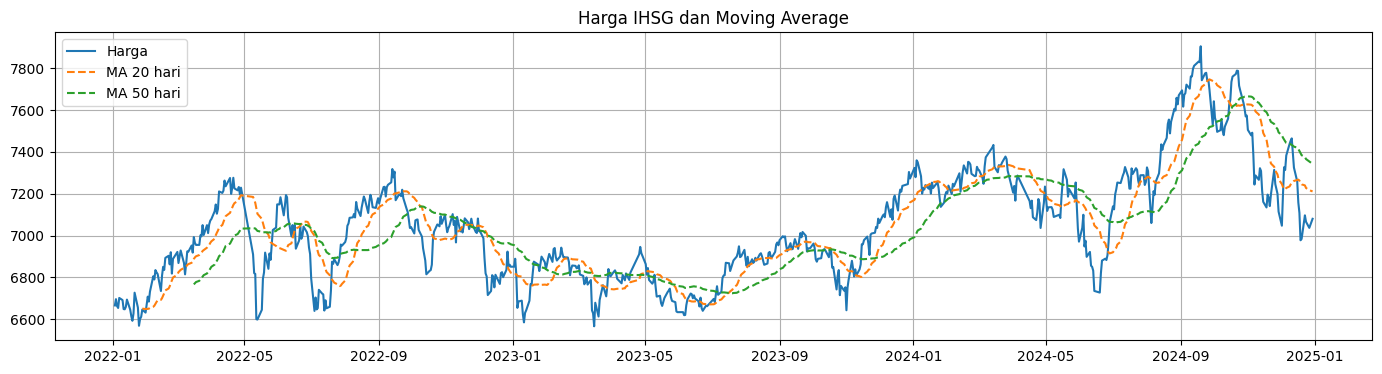

In [ ]:
data['MA20'] = data['Terakhir'].rolling(window=20).mean()  # 1 bulan
data['MA50'] = data['Terakhir'].rolling(window=50).mean()  # 2.5 bulan

plt.figure(figsize=(17,4))
plt.plot(data['Tanggal'], data['Terakhir'], label='Harga')
plt.plot(data['Tanggal'], data['MA20'], label='MA 20 hari', linestyle='--')
plt.plot(data['Tanggal'], data['MA50'], label='MA 50 hari', linestyle='--')
plt.legend()
plt.title('Harga IHSG dan Moving Average')
plt.grid()
plt.show()

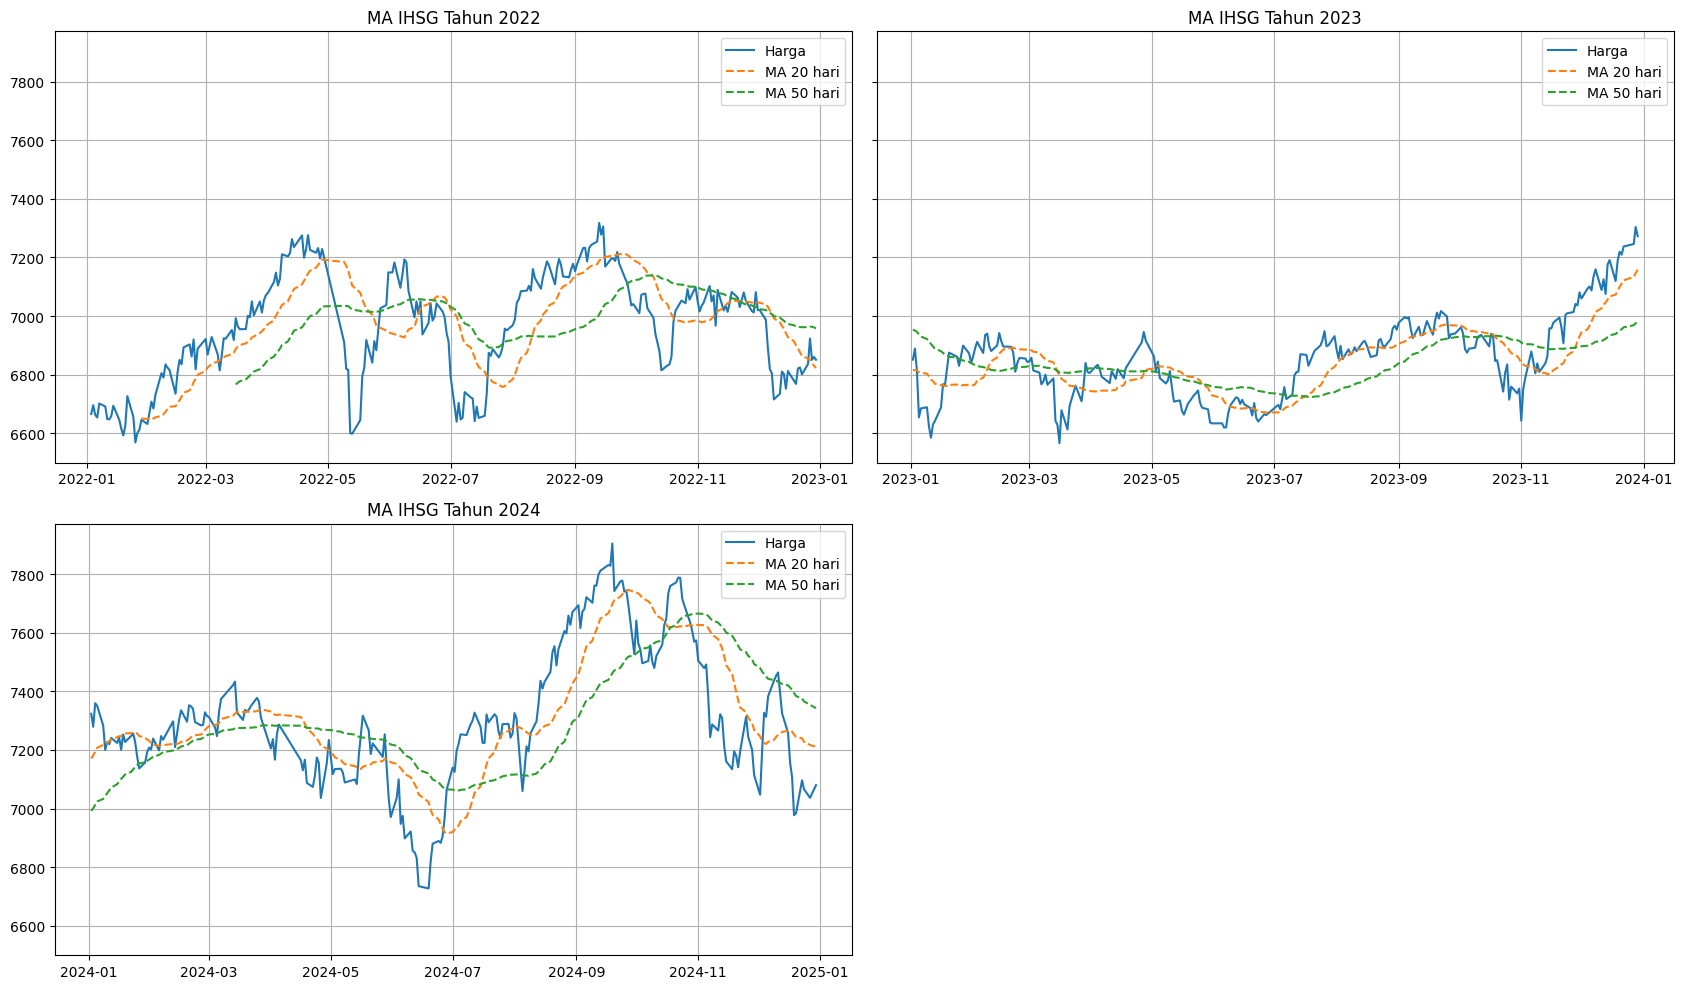

In [ ]:
# Hitung Moving Average
data['MA20'] = data['Terakhir'].rolling(window=20).mean()
data['MA50'] = data['Terakhir'].rolling(window=50).mean()
data['Tahun'] = data['Tanggal'].dt.year

n = len(tahun_unik)
ncols = 2
nrows = (n + 1) // ncols

# Plot per tahun
fig, axs = plt.subplots(nrows, ncols, figsize=(17, 10), sharey=True)
axs = axs.flatten()

for i, tahun in enumerate(tahun_unik):
    df_tahun = data[data['Tahun'] == tahun]
    axs[i].plot(df_tahun['Tanggal'], df_tahun['Terakhir'], label='Harga')
    axs[i].plot(df_tahun['Tanggal'], df_tahun['MA20'], label='MA 20 hari', linestyle='--')
    axs[i].plot(df_tahun['Tanggal'], df_tahun['MA50'], label='MA 50 hari', linestyle='--')
    axs[i].set_title(f'MA IHSG Tahun {tahun}')
    axs[i].grid()
    axs[i].legend()

# Kosongkan subplot jika tidak terpakai
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.tight_layout()
plt.show()

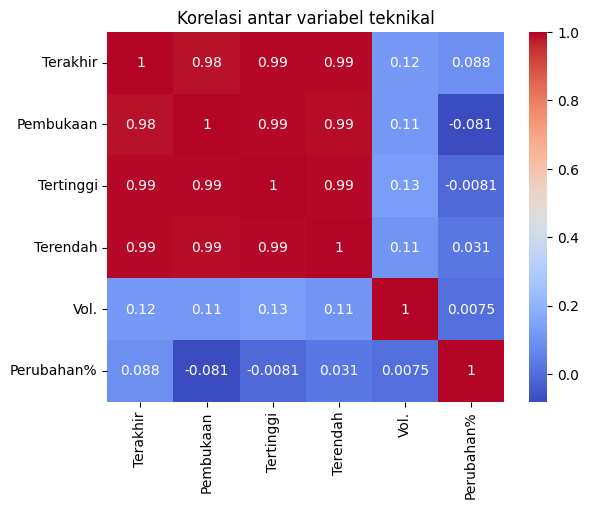

In [ ]:
# sns.heatmap(data[['Terakhir','Pembukaan','Tertinggi','Terendah','Vol.','Perubahan%','Return']].corr(), annot=True, cmap='coolwarm')
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(data[['Terakhir','Pembukaan','Tertinggi','Terendah', 'Vol.','Perubahan%']].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi antar variabel teknikal')
plt.show()

# memahami hubungan antar fitur. Menentukan fitur mana yang paling relevan terhadap return

Skewness  : 0.6810316520335458
Kurtosis  : 0.18727036266190034


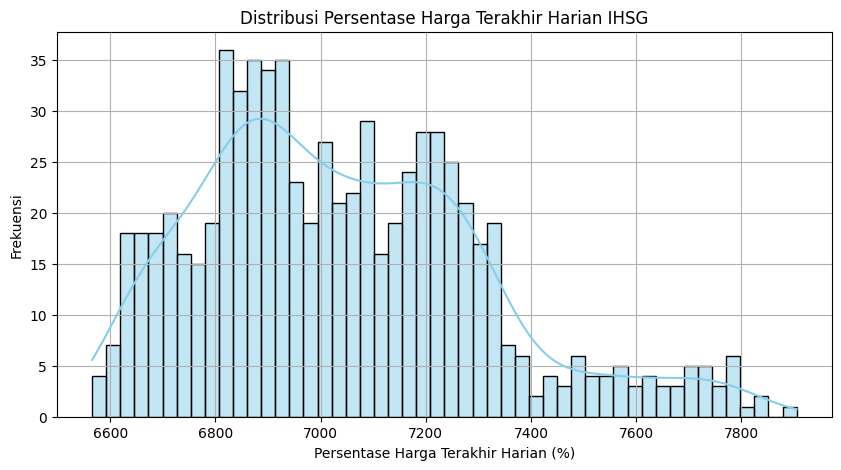

In [ ]:
# Distribusi Return Harian
from scipy.stats import skew, kurtosis
plt.figure(figsize=(10,5))
sns.histplot(data['Terakhir'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Distribusi Persentase Harga Terakhir Harian IHSG')
plt.xlabel('Persentase Harga Terakhir Harian (%)')
plt.ylabel('Frekuensi')
plt.grid()

# Statistik tambahan
print("Skewness  :", skew(data['Terakhir'].dropna()))
print("Kurtosis  :", kurtosis(data['Terakhir'].dropna()))

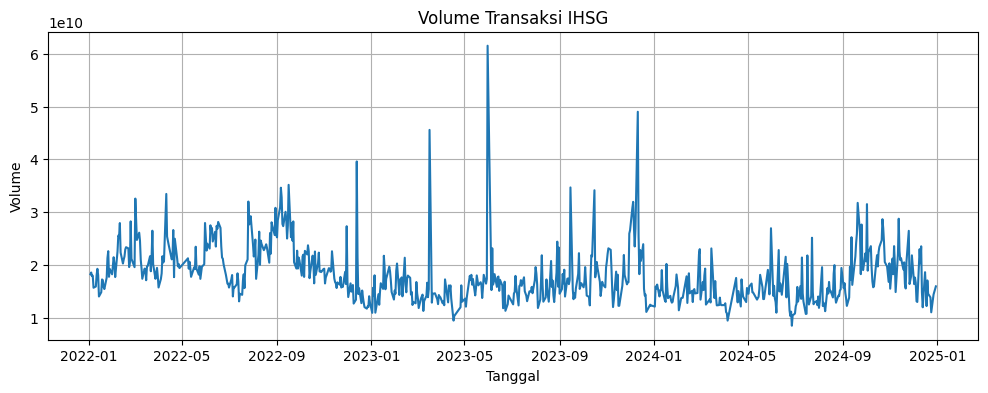

In [ ]:
# Volume Transaksi

plt.figure(figsize=(12,4))
plt.plot(data['Tanggal'], data['Vol.'])
plt.title('Volume Transaksi IHSG')
plt.xlabel('Tanggal')
plt.ylabel('Volume')
plt.grid()

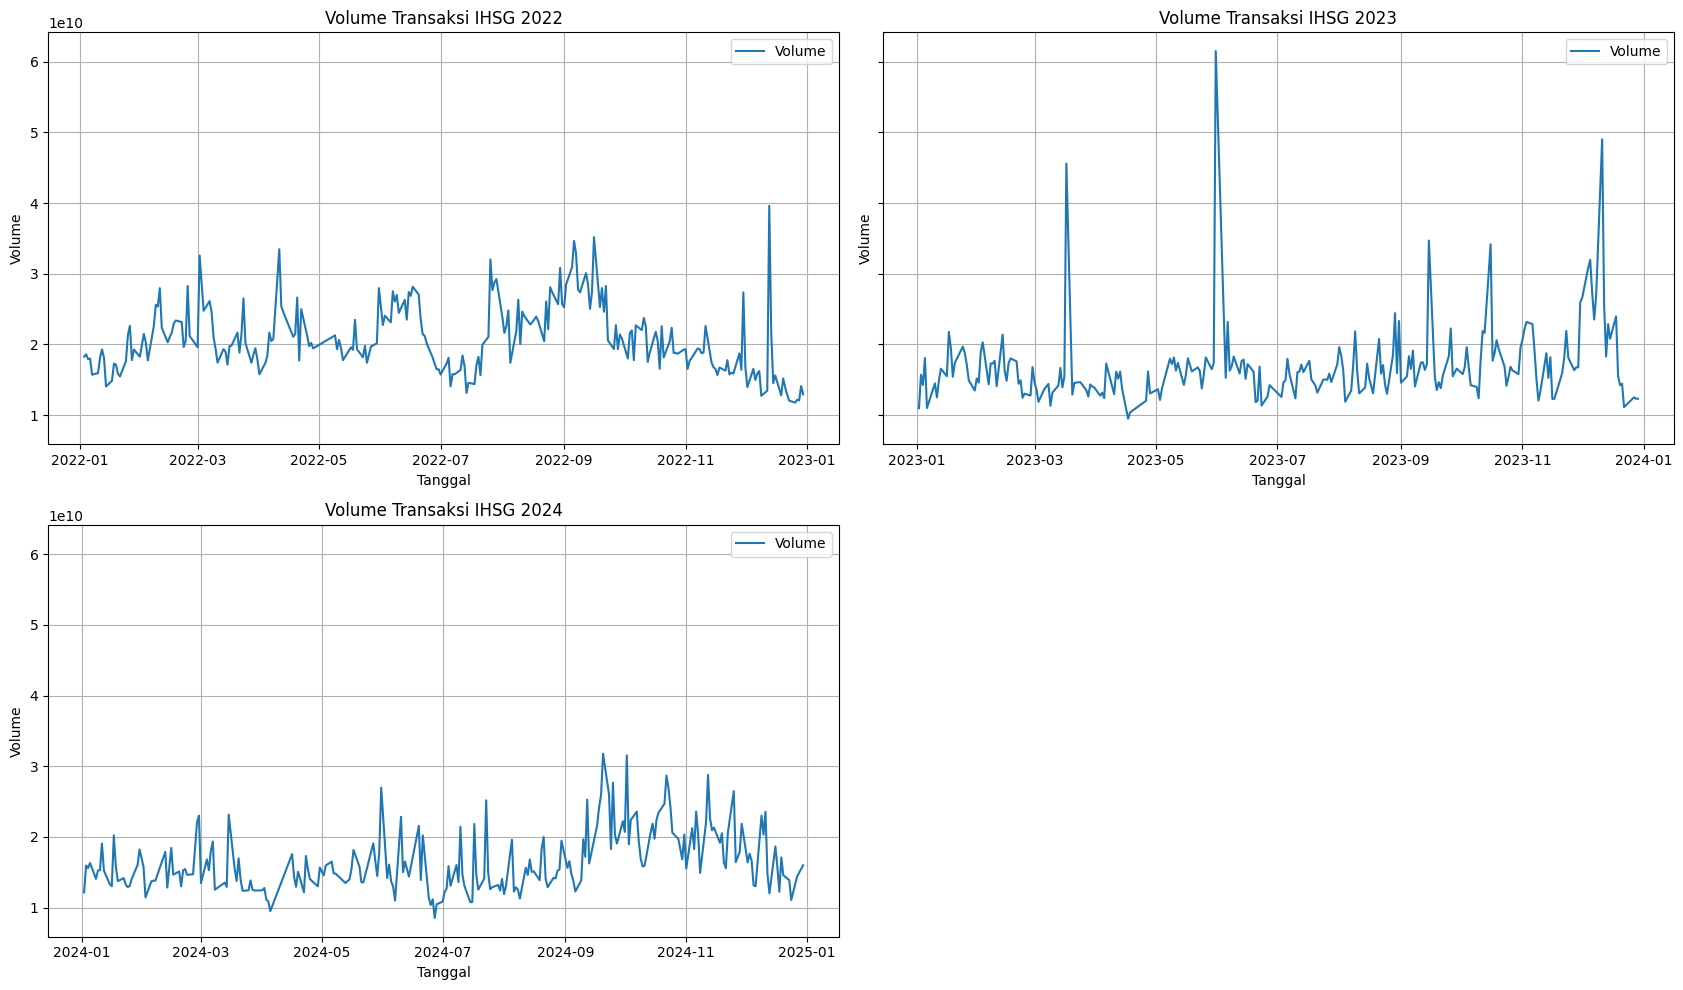

In [ ]:
n = len(tahun_unik)
ncols = 2
nrows = (n + 1) // ncols

fig, axs = plt.subplots(nrows, ncols, figsize=(17, 10), sharey=True)
axs = axs.flatten()

for i, tahun in enumerate(tahun_unik):
    df_tahun = data[data['Tahun'] == tahun]
    axs[i].plot(df_tahun['Tanggal'], df_tahun['Vol.'], label='Volume')
    axs[i].set_title(f'Volume Transaksi IHSG {tahun}')
    axs[i].set_xlabel('Tanggal')
    axs[i].set_ylabel('Volume')
    axs[i].grid(True)
    axs[i].legend()

# Kosongkan subplot yang tidak terpakai
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.tight_layout()
plt.show()